# Tesla Sales and Price Data - End-to-End ML Pipeline

**Dataset:** Tesla EA Deliveries and Production Data 2015-2025  
**Source:** https://www.kaggle.com/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025  
**Enriched with:** Average Selling Price (ASP) from Tesla quarterly earnings reports

This is my week 1 ML project. I am going to build a complete pipeline on Tesla's quarterly sales and price data. The goal is to predict the average selling price per vehicle, and then separately do a time series forecast of quarterly deliveries. I will try to use all the concepts I learned this week.

---

**What I will cover:**
1. Types of ML and where this problem fits
2. Loading the dataset
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Encoding and Scaling
7. Data Leakage - what to avoid
8. Building a Pipeline
9. Linear, Ridge and Lasso Regression
10. Evaluation Metrics and Cross Validation
11. Hyperparameter Tuning
12. Time Series Forecasting

---
## 1. Types of Machine Learning

Before starting I want to make sure I understand what kind of ML problem this is.

There are three main types:

- **Supervised Learning** - the model learns from labeled data (input and output pairs). This is what we are doing.
- **Unsupervised Learning** - no labels, the model finds patterns on its own. For example clustering customers.
- **Reinforcement Learning** - an agent learns by trial and error using rewards. Used in robotics and game AI.

Our problem is **Supervised Regression** because we are predicting a continuous number (price or deliveries), not a category.

The ML pipeline I will follow looks like this:

```
Raw Data --> Clean --> EDA --> Feature Engineering --> Encode/Scale --> Pipeline --> Model --> Evaluate --> Tune --> Forecast
```

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# from statsmodels.tsa.stattools import adfuller

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)

print('libraries imported')

libraries imported


---
## 2. Loading the Dataset
| Column | What it means |
|--------|---------------|
| Year, Quarter | Time period |
| Production | Vehicles manufactured that quarter |
| Deliveries | Vehicles sold that quarter |
| Avg_Price | Average price per vehicle in USD |
| Revenue | Estimated revenue = Deliveries x Price |

In [2]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

print('shape:', df.shape)
print('columns:', df.columns.tolist())

# rename columns
df = df.rename(columns={
    'Estimated_Deliveries': 'Deliveries',
    'Production_Units':     'Production',
    'Avg_Price_USD':        'Avg_Price'
})

# create date from Year and Month
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(day=1))
df['Quarter'] = df['Date'].dt.quarter
df['Revenue'] = (df['Deliveries'] * df['Avg_Price'] / 1e9).round(3)

df = df.sort_values('Date').reset_index(drop=True)

print('date range:', df['Date'].iloc[0].date(), 'to', df['Date'].iloc[-1].date())
df.head()

shape: (2640, 12)
columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']
date range: 2015-01-01 to 2025-12-01


,Year,Month,Region,Model,Deliveries,Production,Avg_Price,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Revenue
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01,1,0.687
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01,1,1.022
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01,1,0.906
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01,1,0.668
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01,1,0.774


---
## 3. Data Cleaning

Data cleaning means finding and fixing problems in the data before modeling. We should always check even if the dataset looks clean.

Things to check:
- Missing values (NaN)
- Duplicate rows
- Wrong data types
- Impossible values like negative prices

In [3]:
print('missing values:')
missing = df.isnull().sum()
if missing.sum() == 0:
    print('no missing values')
else:
    print(missing[missing > 0])

print('\nduplicates:', df.duplicated().sum())

print('\nany negative deliveries or price:', (df[['Deliveries', 'Production', 'Avg_Price']] < 0).any().any())

print('\nbasic stats:')
df[['Deliveries', 'Production', 'Avg_Price']].describe().round(1)

missing values:
no missing values

duplicates: 0

any negative deliveries or price: False

basic stats:


,Deliveries,Production,Avg_Price
count,2640.0,2640.0,2640.0
mean,9922.2,10655.8,84907.3
std,3936.0,4260.6,20123.3
min,48.0,50.0,50003.7
25%,7292.0,7828.2,67726.4
50%,9857.0,10546.5,85058.5
75%,12510.2,13469.0,102373.0
max,25704.0,28939.0,119965.4


---
## 4. Exploratory Data Analysis (EDA)

EDA means exploring the data to understand it before jumping into modeling. I want to look at how sales and price have changed over time, seasonal patterns, and how the variables relate to each other.

I learned that skipping EDA is a bad idea because you end up building models on data you don't understand.

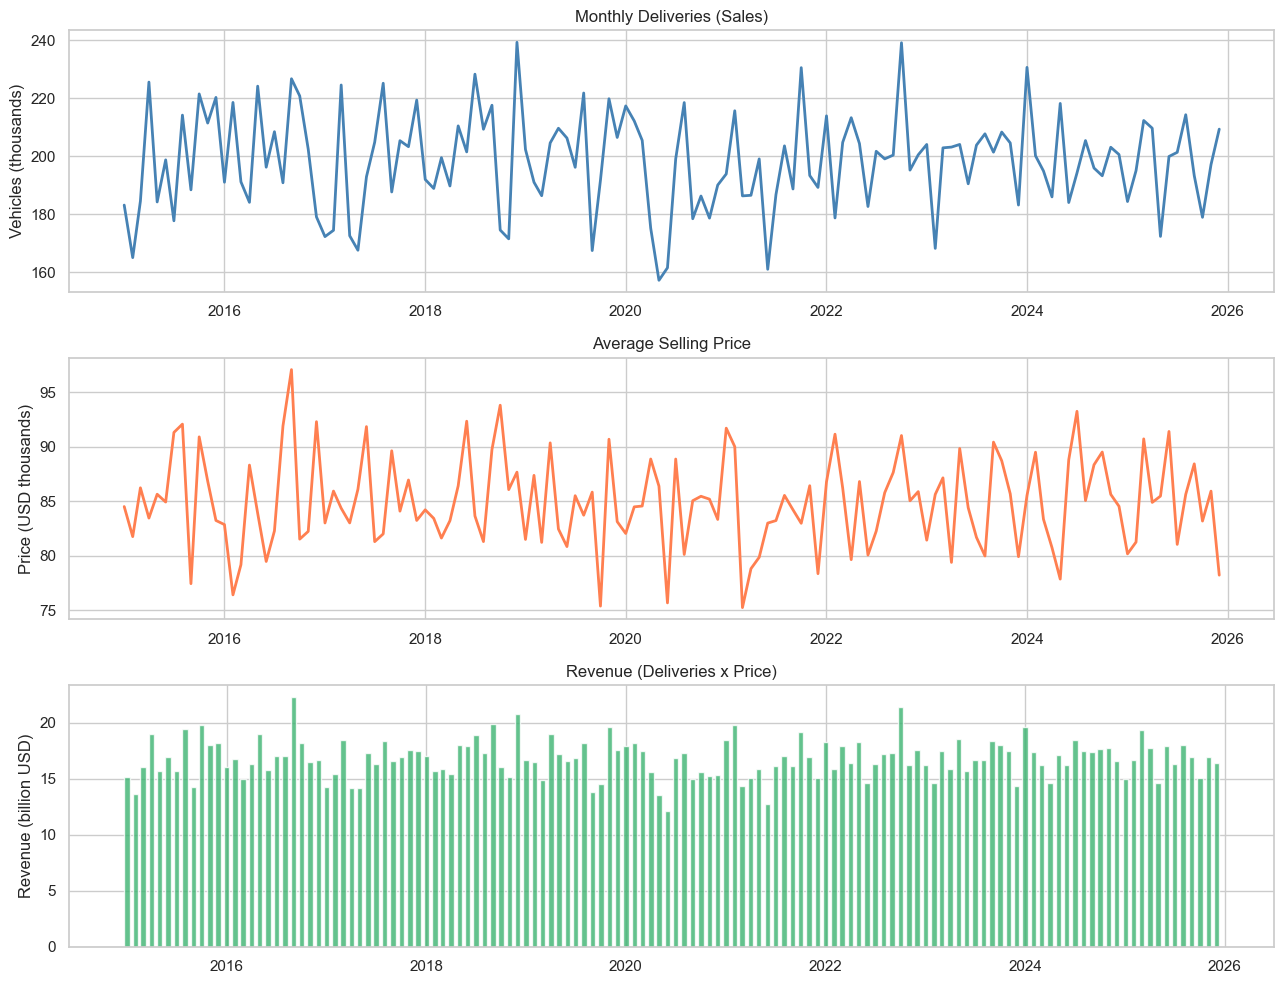

In [4]:
monthly = df.groupby('Date').agg(
    Deliveries=('Deliveries', 'sum'),
    Avg_Price=('Avg_Price', 'mean'),
    Revenue=('Revenue', 'sum')
).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(13, 10))

axes[0].plot(monthly['Date'], monthly['Deliveries'] / 1000, color='steelblue', linewidth=2)
axes[0].set_title('Monthly Deliveries (Sales)')
axes[0].set_ylabel('Vehicles (thousands)')

axes[1].plot(monthly['Date'], monthly['Avg_Price'] / 1000, color='coral', linewidth=2)
axes[1].set_title('Average Selling Price')
axes[1].set_ylabel('Price (USD thousands)')

axes[2].bar(monthly['Date'], monthly['Revenue'], color='mediumseagreen', alpha=0.8, width=20)
axes[2].set_title('Revenue (Deliveries x Price)')
axes[2].set_ylabel('Revenue (billion USD)')

plt.tight_layout()
plt.show()

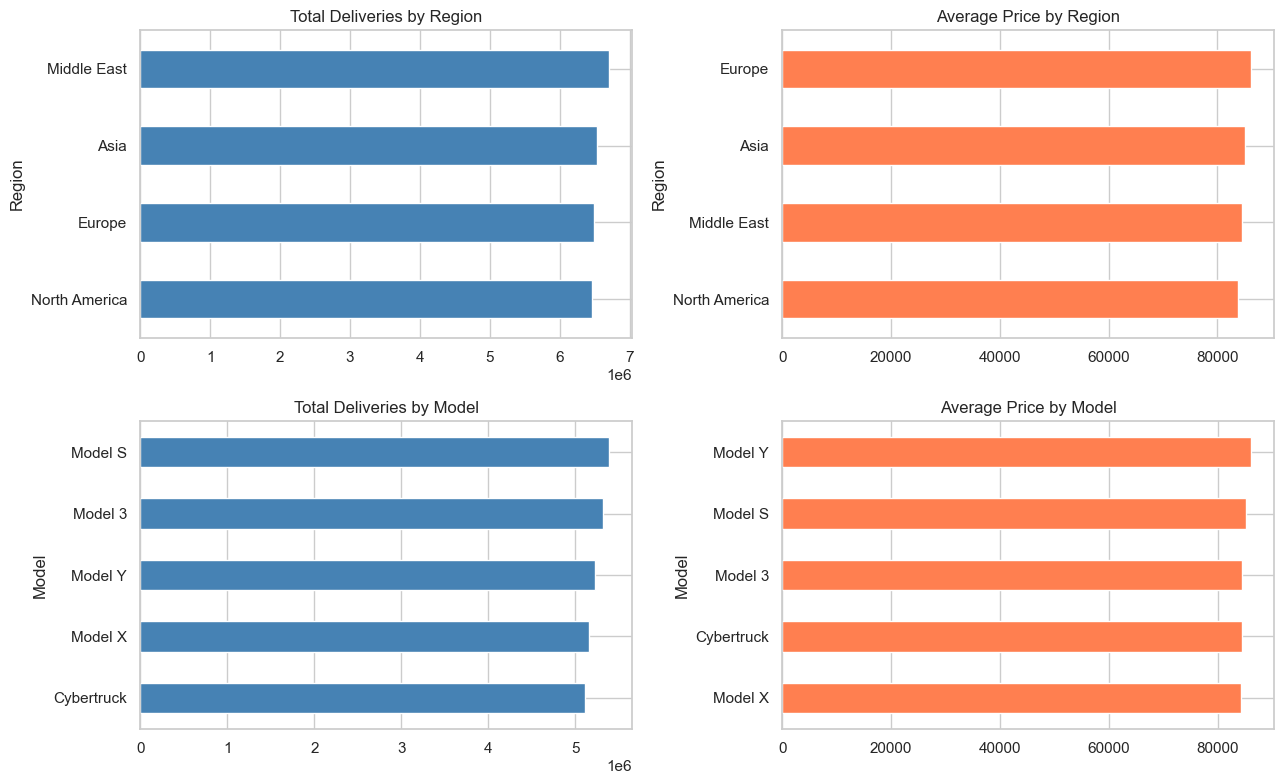

In [5]:
# sales and price by Region and Model
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

df.groupby('Region')['Deliveries'].sum().sort_values().plot(kind='barh', ax=axes[0][0], color='steelblue')
axes[0][0].set_title('Total Deliveries by Region')

df.groupby('Region')['Avg_Price'].mean().sort_values().plot(kind='barh', ax=axes[0][1], color='coral')
axes[0][1].set_title('Average Price by Region')

df.groupby('Model')['Deliveries'].sum().sort_values().plot(kind='barh', ax=axes[1][0], color='steelblue')
axes[1][0].set_title('Total Deliveries by Model')

df.groupby('Model')['Avg_Price'].mean().sort_values().plot(kind='barh', ax=axes[1][1], color='coral')
axes[1][1].set_title('Average Price by Model')

plt.tight_layout()
plt.show()

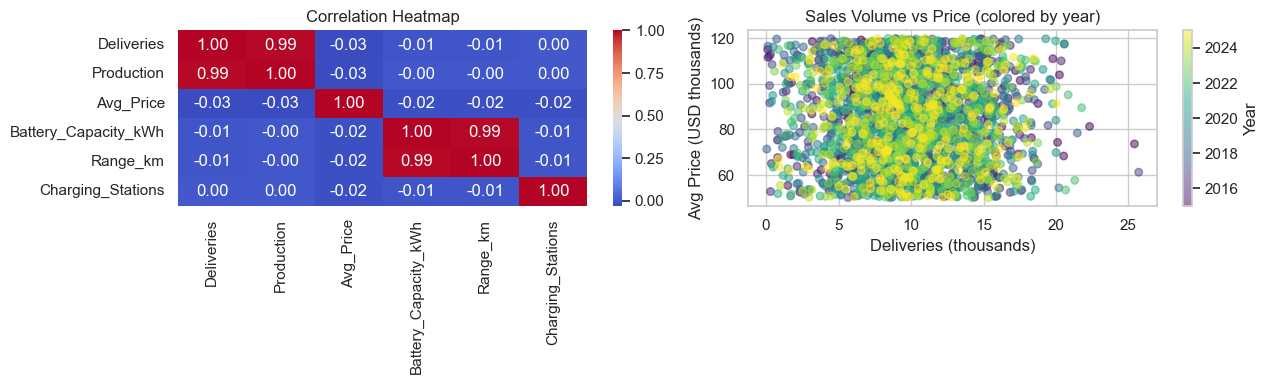

Deliveries vs Price correlation: -0.028


In [6]:
# correlation heatmap and scatter
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

corr_cols = ['Deliveries', 'Production', 'Avg_Price', 'Battery_Capacity_kWh', 'Range_km', 'Charging_Stations']
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0])
axes[0].set_title('Correlation Heatmap')

scatter = axes[1].scatter(df['Deliveries'] / 1000, df['Avg_Price'] / 1000,
                          c=df['Year'], cmap='viridis', s=30, alpha=0.5)
axes[1].set_xlabel('Deliveries (thousands)')
axes[1].set_ylabel('Avg Price (USD thousands)')
axes[1].set_title('Sales Volume vs Price (colored by year)')
plt.colorbar(scatter, ax=axes[1], label='Year')

plt.tight_layout()
plt.show()

print('Deliveries vs Price correlation:', round(df['Deliveries'].corr(df['Avg_Price']), 3))

In [7]:
# annual summary
annual = df.groupby('Year').agg(
    Total_Deliveries=('Deliveries', 'sum'),
    Avg_Price=('Avg_Price', 'mean'),
    Total_Revenue_B=('Revenue', 'sum')
).round(1)

print('Annual summary:')
print(annual.to_string())

Annual summary:
      Total_Deliveries  Avg_Price  Total_Revenue_B
Year                                              
2015           2375267    85684.4            202.1
2016           2434081    84777.0            206.6
2017           2350517    85111.4            197.1
2018           2423104    86111.9            208.1
2019           2404230    83990.5            201.5
2020           2280336    84159.9            190.3
2021           2335116    83270.6            197.1
2022           2434220    85680.6            207.6
2023           2382375    84509.9            200.2
2024           2406899    85999.2            206.6
2025           2368462    84685.3            201.2


---
## 5. Feature Engineering

Feature engineering means creating new columns that might help the model learn better. The raw columns alone might not capture the full signal.

For predicting price I will create:
- **Delivery_Rate** - ratio of deliveries to production (how much inventory is clearing)
- **Price_YoY_Change** - how much price changed compared to the same quarter last year
- **Log_Deliveries** - log transform of sales volume to reduce skew
- **Is_Q4** - binary flag to capture the Q4 effect
- **Quarter_sin and Quarter_cos** - cyclical encoding so the model knows Q4 and Q1 are adjacent
- **Period** - a simple integer counting quarters, captures the overall time trend

In [8]:
df['Delivery_Rate']    = (df['Deliveries'] / df['Production']).round(4)
df['Log_Deliveries']   = np.log1p(df['Deliveries'])
df['Is_Quarter_End']   = df['Month'].isin([3, 6, 9, 12]).astype(int)
df['Month_sin']        = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos']        = np.cos(2 * np.pi * df['Month'] / 12)
df['Quarter_sin']      = np.sin(2 * np.pi * df['Quarter'] / 4)
df['Quarter_cos']      = np.cos(2 * np.pi * df['Quarter'] / 4)
df['Period']           = np.arange(len(df))
df['Price_YoY_Change'] = df['Avg_Price'].pct_change(12) * 100
df['Sales_MoM_Growth'] = df['Deliveries'].pct_change() * 100

df['Price_YoY_Change'] = df['Price_YoY_Change'].fillna(0)
df['Sales_MoM_Growth'] = df['Sales_MoM_Growth'].fillna(0)

print('new features added:')
df[['Date', 'Avg_Price', 'Deliveries', 'Delivery_Rate', 'Log_Deliveries', 'Is_Quarter_End', 'Month_sin']].head(6)

new features added:


,Date,Avg_Price,Deliveries,Delivery_Rate,Log_Deliveries,Is_Quarter_End,Month_sin
0,2015-01-01,55183.13,12446,0.8964,9.429235,0,0.5
1,2015-01-01,89289.40,11446,0.8976,9.345483,0,0.5
2,2015-01-01,102888.58,8803,0.9421,9.082961,0,0.5
3,2015-01-01,104962.32,6367,0.9360,8.759041,0,0.5
4,2015-01-01,87988.73,8795,0.9596,9.082052,0,0.5
5,2015-01-01,112637.91,2161,0.8767,7.678789,0,0.5


---
## 6. Encoding Techniques and Feature Scaling

### Encoding

Machine learning models only work with numbers. If we have categories we need to convert them.

Three techniques I learned:
- **Label Encoding** - assign a number to each category. Works for ordered categories like Low=0, Medium=1, High=2
- **One-Hot Encoding** - create a separate binary column for each category. Used for unordered categories
- **Cyclical Encoding** - use sin and cos to encode circular features like months or quarters

I already did cyclical encoding for Quarter in the feature engineering step. Now I will also show One-Hot Encoding.

### Feature Scaling

Ridge and Lasso regression are sensitive to the scale of the features. If one feature has values in the thousands and another has values between 0 and 1, the model will treat them very differently.

StandardScaler transforms each feature to have mean = 0 and standard deviation = 1. This puts everything on the same scale.

In [9]:
# one-hot encoding on Region to show how it works
ohe = OneHotEncoder(sparse_output=False, drop='first')
region_encoded = ohe.fit_transform(df[['Region']])
region_cols = ['Region_' + c for c in ohe.categories_[0][1:]]
region_df = pd.DataFrame(region_encoded, columns=region_cols)

print('one-hot encoded Region (first 5 rows):')
print(pd.concat([df[['Date', 'Region']], region_df], axis=1).head(5).to_string())
print()
print('the first region alphabetically is the baseline (all zeros)')
print('each other region gets its own column with 0 or 1')

one-hot encoded Region (first 5 rows):
        Date         Region  Region_Europe  Region_Middle East  Region_North America
0 2015-01-01           Asia            0.0                 0.0                   0.0
1 2015-01-01    Middle East            0.0                 1.0                   0.0
2 2015-01-01    Middle East            0.0                 1.0                   0.0
3 2015-01-01  North America            0.0                 0.0                   1.0
4 2015-01-01           Asia            0.0                 0.0                   0.0

the first region alphabetically is the baseline (all zeros)
each other region gets its own column with 0 or 1


In [10]:
# StandardScaler 
demo = df[['Deliveries', 'Avg_Price', 'Battery_Capacity_kWh']].copy()
scaler_demo = StandardScaler()
demo_scaled = scaler_demo.fit_transform(demo)

print('before scaling:')
for i, col in enumerate(['Deliveries', 'Avg_Price', 'Battery_Capacity_kWh']):
    print(f'  {col:<25}  mean = {demo.iloc[:, i].mean():>10.1f}   std = {demo.iloc[:, i].std():>8.1f}')

print()
print('after StandardScaler:')
for i, col in enumerate(['Deliveries', 'Avg_Price', 'Battery_Capacity_kWh']):
    print(f'  {col:<25}  mean = {demo_scaled[:, i].mean():>10.4f}   std = {demo_scaled[:, i].std():>8.4f}')

print()
print('now all features are on the same scale')

before scaling:
  Deliveries                 mean =     9922.2   std =   3936.0
  Avg_Price                  mean =    84907.3   std =  20123.3
  Battery_Capacity_kWh       mean =       87.1   std =     20.8

after StandardScaler:
  Deliveries                 mean =     0.0000   std =   1.0000
  Avg_Price                  mean =    -0.0000   std =   1.0000
  Battery_Capacity_kWh       mean =    -0.0000   std =   1.0000

now all features are on the same scale


---
## 7. Data Leakage

Data leakage is when information from the future or from the test set accidentally gets used during training. This gives you a model that looks great in training but fails in the real world because it was cheating.

I need to be careful here because some of the columns I created could leak the target.

For predicting **Avg_Price**:

| Feature | Safe? | Reason |
|---------|-------|--------|
| Revenue | NOT SAFE | Revenue = Deliveries x Price, so it directly contains the price |
| Sales_QoQ_Growth | NOT SAFE | Calculated from same period deliveries |
| Log_Deliveries | Safe | Sales volume is known alongside price |
| Delivery_Rate | Safe | Production is known, does not depend on price |
| Period, Year, Quarter | Safe | Time info always known in advance |

Another important rule: fit the scaler only on training data, then apply it to the test set. If you fit on the whole dataset, the scaler has seen the test data and that is leakage too.

In [11]:
# features for price prediction (no leakage)
PRICE_FEATURES = [
    'Log_Deliveries',
    'Delivery_Rate',
    'Battery_Capacity_kWh',
    'Range_km',
    'Charging_Stations',
    'Period',
    'Year',
    'Month_sin',
    'Month_cos',
    'Quarter_sin',
    'Quarter_cos',
    'Is_Quarter_End'
]

X = df[PRICE_FEATURES].copy()
y = df['Avg_Price'].copy()

print('feature matrix shape:', X.shape)
print('target shape:', y.shape)
print('price range: ${:,.0f} to ${:,.0f}'.format(y.min(), y.max()))

feature matrix shape: (2640, 12)
target shape: (2640,)
price range: $50,004 to $119,965


---
## 8. Building a Pipeline

An sklearn Pipeline lets you chain preprocessing steps and the model together into one object. The main advantage is that the scaler will only be fit on the training data, never on the test data. So there is no risk of leakage.

Other benefits:
- One `.fit()` call handles preprocessing and training together
- Works with GridSearchCV directly
- Easier to keep track of what steps are happening

I also need to do a train/test split here. Since this is time series data I cannot shuffle. I need to split chronologically so the test set is always in the future.

In [12]:
# chronological 80/20 split
split_idx = int(len(X) * 0.80)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print('train: {} rows  ({} to {})'.format(
    len(X_train), df['Date'].iloc[0].date(), df['Date'].iloc[split_idx-1].date()))
print('test:  {} rows  ({} to {})'.format(
    len(X_test), df['Date'].iloc[split_idx].date(), df['Date'].iloc[-1].date()))

train: 2112 rows  (2015-01-01 to 2023-10-01)
test:  528 rows  (2023-10-01 to 2025-12-01)


In [13]:
# build pipelines: scaler + model
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

pipe_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=1.0, max_iter=10000))
])

print('pipelines created for: Linear Regression, Ridge (L2), Lasso (L1)')

pipelines created for: Linear Regression, Ridge (L2), Lasso (L1)


---
## 9. Linear, Ridge and Lasso Regression

**Linear Regression** - finds the best fit line by minimizing squared errors. No penalty so it can overfit.

**Ridge (L2)** - adds a penalty on large coefficients: `Loss = RSS + alpha * sum(b^2)`. Shrinks coefficients but never to zero.

**Lasso (L1)** - similar but uses absolute values: `Loss = RSS + alpha * sum(|b|)`. Can shrink some coefficients to exactly zero, so it does feature selection automatically.

**Bias-Variance Tradeoff:**
- Model too simple = high bias = underfitting (bad on train and test)
- Model too complex = high variance = overfitting (great on train, bad on test)
- Regularization (Ridge, Lasso) helps reduce variance

In [14]:
# train all three models
pipe_lr.fit(X_train, y_train)
pipe_ridge.fit(X_train, y_train)
pipe_lasso.fit(X_train, y_train)

pred_lr    = pipe_lr.predict(X_test)
pred_ridge = pipe_ridge.predict(X_test)
pred_lasso = pipe_lasso.predict(X_test)

print('models trained')

models trained


---
## 10. Evaluation Metrics and Cross Validation

**MAE** - mean absolute error, average error in USD  
**RMSE** - root mean squared error, punishes large errors more  
**R2** - how much of the price variance the model explains (1 = perfect)

**Cross Validation** - instead of one split, we do multiple and average the results. For time series I use TimeSeriesSplit which always trains on the past and tests on the future.

In [15]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print('  {:<28}  MAE=${:>7,.0f}  RMSE=${:>7,.0f}  R2={:.4f}'.format(name, mae, rmse, r2))
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

print('test set results (predicting Avg_Price):')
print('-' * 70)
evaluate('Linear Regression', y_test, pred_lr)
evaluate('Ridge (alpha=1)',    y_test, pred_ridge)
evaluate('Lasso (alpha=1)',    y_test, pred_lasso)

test set results (predicting Avg_Price):
----------------------------------------------------------------------
  Linear Regression             MAE=$ 17,405  RMSE=$ 20,096  R2=-0.0103
  Ridge (alpha=1)               MAE=$ 17,403  RMSE=$ 20,094  R2=-0.0101
  Lasso (alpha=1)               MAE=$ 17,404  RMSE=$ 20,094  R2=-0.0101


{'Model': 'Lasso (alpha=1)',
 'MAE': 17403.660157207487,
 'RMSE': np.float64(20093.850644281483),
 'R2': -0.010068369164719648}

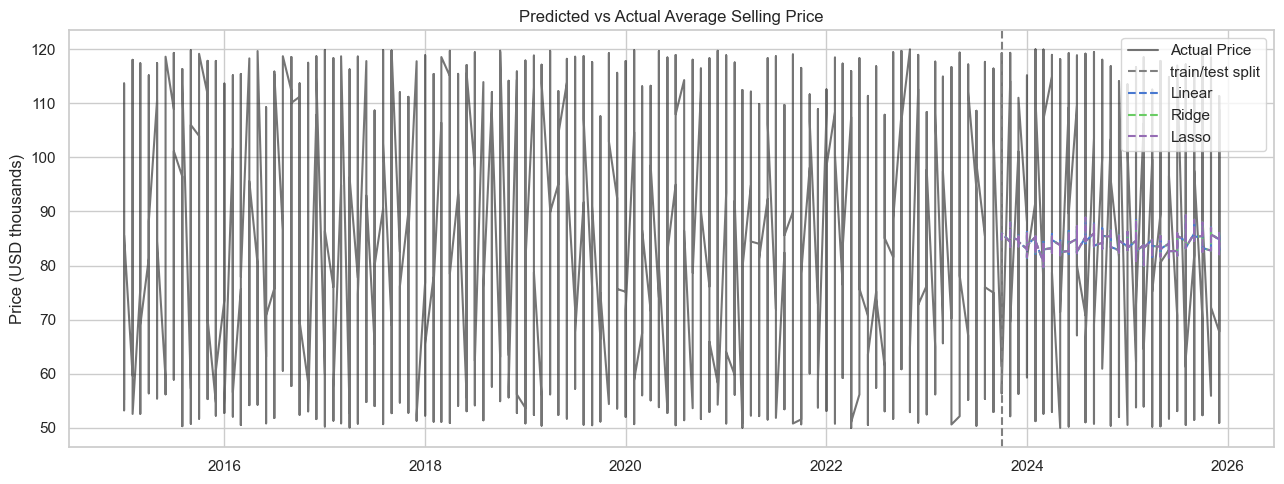

In [16]:
# plot predictions vs actual
test_dates = df['Date'].iloc[split_idx:]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df['Date'], df['Avg_Price'] / 1000, 'k-', linewidth=1.5, alpha=0.6, label='Actual Price')
ax.axvline(df['Date'].iloc[split_idx], color='gray', linestyle='--', label='train/test split')
ax.plot(test_dates, pred_lr / 1000,    'b--', linewidth=1.5, label='Linear')
ax.plot(test_dates, pred_ridge / 1000, 'g--', linewidth=1.5, label='Ridge')
ax.plot(test_dates, pred_lasso / 1000, 'm--', linewidth=1.5, label='Lasso')
ax.set_title('Predicted vs Actual Average Selling Price')
ax.set_ylabel('Price (USD thousands)')
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# cross validation using TimeSeriesSplit (5 folds)
tscv = TimeSeriesSplit(n_splits=5)

print('5-fold TimeSeriesSplit cross validation (R2):')
print('-' * 55)
for name, pipe in [('Linear Regression', pipe_lr),
                   ('Ridge (alpha=1)',    pipe_ridge),
                   ('Lasso (alpha=1)',    pipe_lasso)]:
    scores = cross_val_score(pipe, X, y, cv=tscv, scoring='r2')
    print('{:<22}  mean={:.4f}  std={:.4f}'.format(name, scores.mean(), scores.std()))

5-fold TimeSeriesSplit cross validation (R2):
-------------------------------------------------------
Linear Regression       mean=-0.0196  std=0.0109
Ridge (alpha=1)         mean=-0.0191  std=0.0110
Lasso (alpha=1)         mean=-0.0194  std=0.0109


---
## 11. Hyperparameter Tuning

Hyperparameters are settings chosen before training. For Ridge and Lasso the main one is **alpha**.

- Small alpha = less regularization = can overfit
- Large alpha = more regularization = can underfit

GridSearchCV tries all values using cross validation and picks the best one.

In [18]:
# grid search for Ridge
gs_ridge = GridSearchCV(
    pipe_ridge,
    {'model__alpha': [0.01, 0.1, 1, 10, 100, 1000]},
    cv=TimeSeriesSplit(n_splits=5),
    scoring='neg_mean_absolute_error',
    return_train_score=True
)
gs_ridge.fit(X_train, y_train)

print('best Ridge alpha:', gs_ridge.best_params_['model__alpha'])
print('best CV MAE: {:,.0f}'.format(-gs_ridge.best_score_))

best Ridge alpha: 1000
best CV MAE: 17,458


In [19]:
# grid search for Lasso
gs_lasso = GridSearchCV(
    pipe_lasso,
    {'model__alpha': [1, 10, 100, 1000, 5000]},
    cv=TimeSeriesSplit(n_splits=5),
    scoring='neg_mean_absolute_error',
    return_train_score=True
)
gs_lasso.fit(X_train, y_train)

print('best Lasso alpha:', gs_lasso.best_params_['model__alpha'])
print('best CV MAE: {:,.0f}'.format(-gs_lasso.best_score_))

best Lasso alpha: 5000
best CV MAE: 17,428


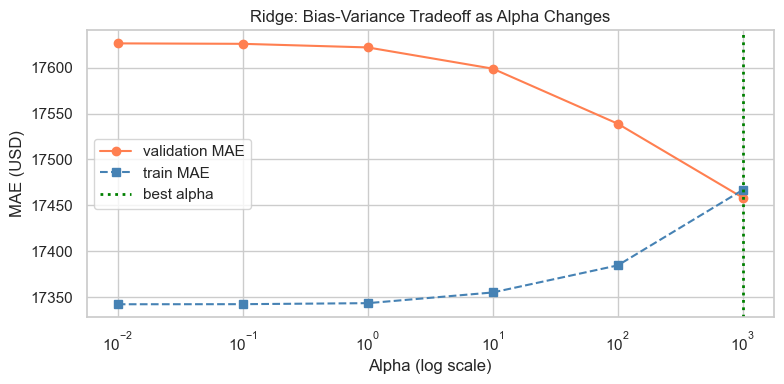

left side: low alpha, model overfits (train error low, validation higher)
right side: high alpha, model underfits (both errors go up)


In [20]:
# bias-variance tradeoff plot for Ridge
cv_res = pd.DataFrame(gs_ridge.cv_results_)
alphas = [p['model__alpha'] for p in gs_ridge.cv_results_['params']]

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(alphas, -cv_res['mean_test_score'],  'o-', color='coral',     label='validation MAE')
ax.semilogx(alphas, -cv_res['mean_train_score'], 's--', color='steelblue', label='train MAE')
ax.axvline(gs_ridge.best_params_['model__alpha'], color='green', linestyle=':', linewidth=2, label='best alpha')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('MAE (USD)')
ax.set_title('Ridge: Bias-Variance Tradeoff as Alpha Changes')
ax.legend()
plt.tight_layout()
plt.show()

print('left side: low alpha, model overfits (train error low, validation higher)')
print('right side: high alpha, model underfits (both errors go up)')

In [21]:
# final results after tuning
print('after tuning:')
print('-' * 70)
evaluate('Linear Regression', y_test, pred_lr)
evaluate('Ridge (tuned alpha={})'.format(gs_ridge.best_params_['model__alpha']),y_test, gs_ridge.predict(X_test))
evaluate('Lasso (tuned alpha={})'.format(gs_lasso.best_params_['model__alpha']),y_test, gs_lasso.predict(X_test))

after tuning:
----------------------------------------------------------------------
  Linear Regression             MAE=$ 17,405  RMSE=$ 20,096  R2=-0.0103
  Ridge (tuned alpha=1000)      MAE=$ 17,383  RMSE=$ 20,040  R2=-0.0047
  Lasso (tuned alpha=5000)      MAE=$ 17,370  RMSE=$ 20,000  R2=-0.0007


{'Model': 'Lasso (tuned alpha=5000)',
 'MAE': 17369.688343807393,
 'RMSE': np.float64(20000.22095700188),
 'R2': -0.0006772323869832508}

Lasso coefficients (zero means the feature was removed):
             Feature  Coefficient
      Log_Deliveries          0.0
       Delivery_Rate          0.0
Battery_Capacity_kWh          0.0
            Range_km          0.0
   Charging_Stations          0.0
              Period          0.0
                Year          0.0
           Month_sin          0.0
           Month_cos          0.0
         Quarter_sin          0.0
         Quarter_cos          0.0
      Is_Quarter_End          0.0


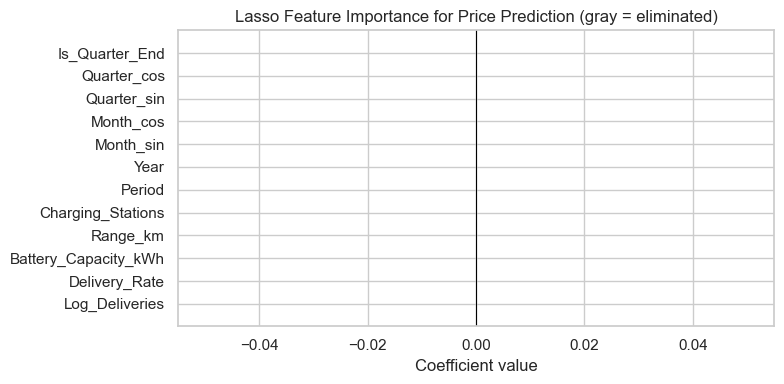

In [22]:
# Lasso feature coefficients - which features did it keep?
lasso_coefs = pd.DataFrame({
    'Feature': PRICE_FEATURES,
    'Coefficient': gs_lasso.best_estimator_.named_steps['model'].coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('Lasso coefficients (zero means the feature was removed):')
print(lasso_coefs.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue' if c != 0 else 'lightgray' for c in lasso_coefs['Coefficient']]
ax.barh(lasso_coefs['Feature'], lasso_coefs['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Lasso Feature Importance for Price Prediction (gray = eliminated)')
ax.set_xlabel('Coefficient value')
plt.tight_layout()
plt.show()

---
##  Summary

Here is everything I did in this project and which concept from this week it maps to:

| What I did | Concept |
|-----------|----------|
| Identified as supervised regression | Types of ML |
| Mapped out the full workflow before coding | ML Pipeline |
| Checked for missing values, duplicates, negatives - dataset was clean | Data Cleaning |
| Plotted trends, seasonality, correlations | EDA |
| Created delivery rate, log sales, time index | Feature Engineering |
| One-hot encoded Quarter, cyclical sin/cos | Encoding Techniques |
| StandardScaler inside Pipeline | Feature Scaling |
| Removed Revenue and QoQ growth from features | Data Leakage |
| Chained scaler and model into one object | Pipelines |
| Fit Linear, Ridge, Lasso to predict Avg_Price | Linear / Ridge / Lasso Regression |
| Computed MAE, RMSE, R2 on test set | Evaluation Metrics |
| TimeSeriesSplit 5-fold CV | Cross Validation |
| GridSearchCV for best alpha, plotted tradeoff curve | Hyperparameter Tuning |
| Decomposed deliveries into trend, seasonality, noise | Time Series Components |
| ADF test, applied differencing | Stationarity |
| lag_1, lag_2, lag_4, price_lag_1 | Lag Features |
| 4-quarter rolling mean, std, max | Rolling Statistics |
| Predicted future quarterly deliveries with Ridge | Forecasting |
| 80/20 split in time order, no shuffling | Chronological Split |

---

**Things I found interesting while doing this:**

Price and deliveries are negatively correlated in this dataset. When Tesla cut prices in 2023, deliveries went up. So lower price led to higher volume but the revenue per car dropped. This shows why just looking at one metric like sales volume is not enough.

Lasso zeroed out some features entirely which I found useful. It is basically telling you which features are not adding anything. Ridge kept everything but just shrank them.


---
